In [2]:
#important libraries
import numpy as np
import pandas as pd
import os
import cv2
import seaborn as sns 
import matplotlib.pyplot as plt
import pickle
from tqdm import tqdm
from keras.models import Sequential,Model,load_model
from keras.layers import Dense,Dropout,BatchNormalization,Conv2D,MaxPooling2D,Input,Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img,img_to_array
from keras.callbacks import ReduceLROnPlateau,EarlyStopping,ModelCheckpoint
from sklearn.metrics import classification_report,confusion_matrix
import warnings 
warnings.filterwarnings('ignore')

## Read Training Images ,Split it to (train,validation) and Show them

In [3]:
img_size=(150,150)
batch_size=64
seed=42
epochs=30

In [4]:
train_dir=r'/kaggle/input/datasets/tr1gg3rtrash/balanced-augmented-covid-cxr-dataset'
train_generator=ImageDataGenerator(rescale=1./255,validation_split=0.2)
train_data=train_generator.flow_from_directory(directory=train_dir,
                                                subset='training',
                                                target_size=img_size,
                                                color_mode='grayscale',
                                                class_mode='categorical',
                                                shuffle=True,
                                                seed=seed,
                                                batch_size=batch_size)

Found 24000 images belonging to 4 classes.


In [5]:
val_data=train_generator.flow_from_directory(directory=train_dir,
                                            subset='validation',
                                            color_mode='grayscale',
                                            class_mode='categorical',
                                            target_size=img_size,
                                            batch_size=batch_size,
                                            shuffle=False)

Found 5998 images belonging to 4 classes.


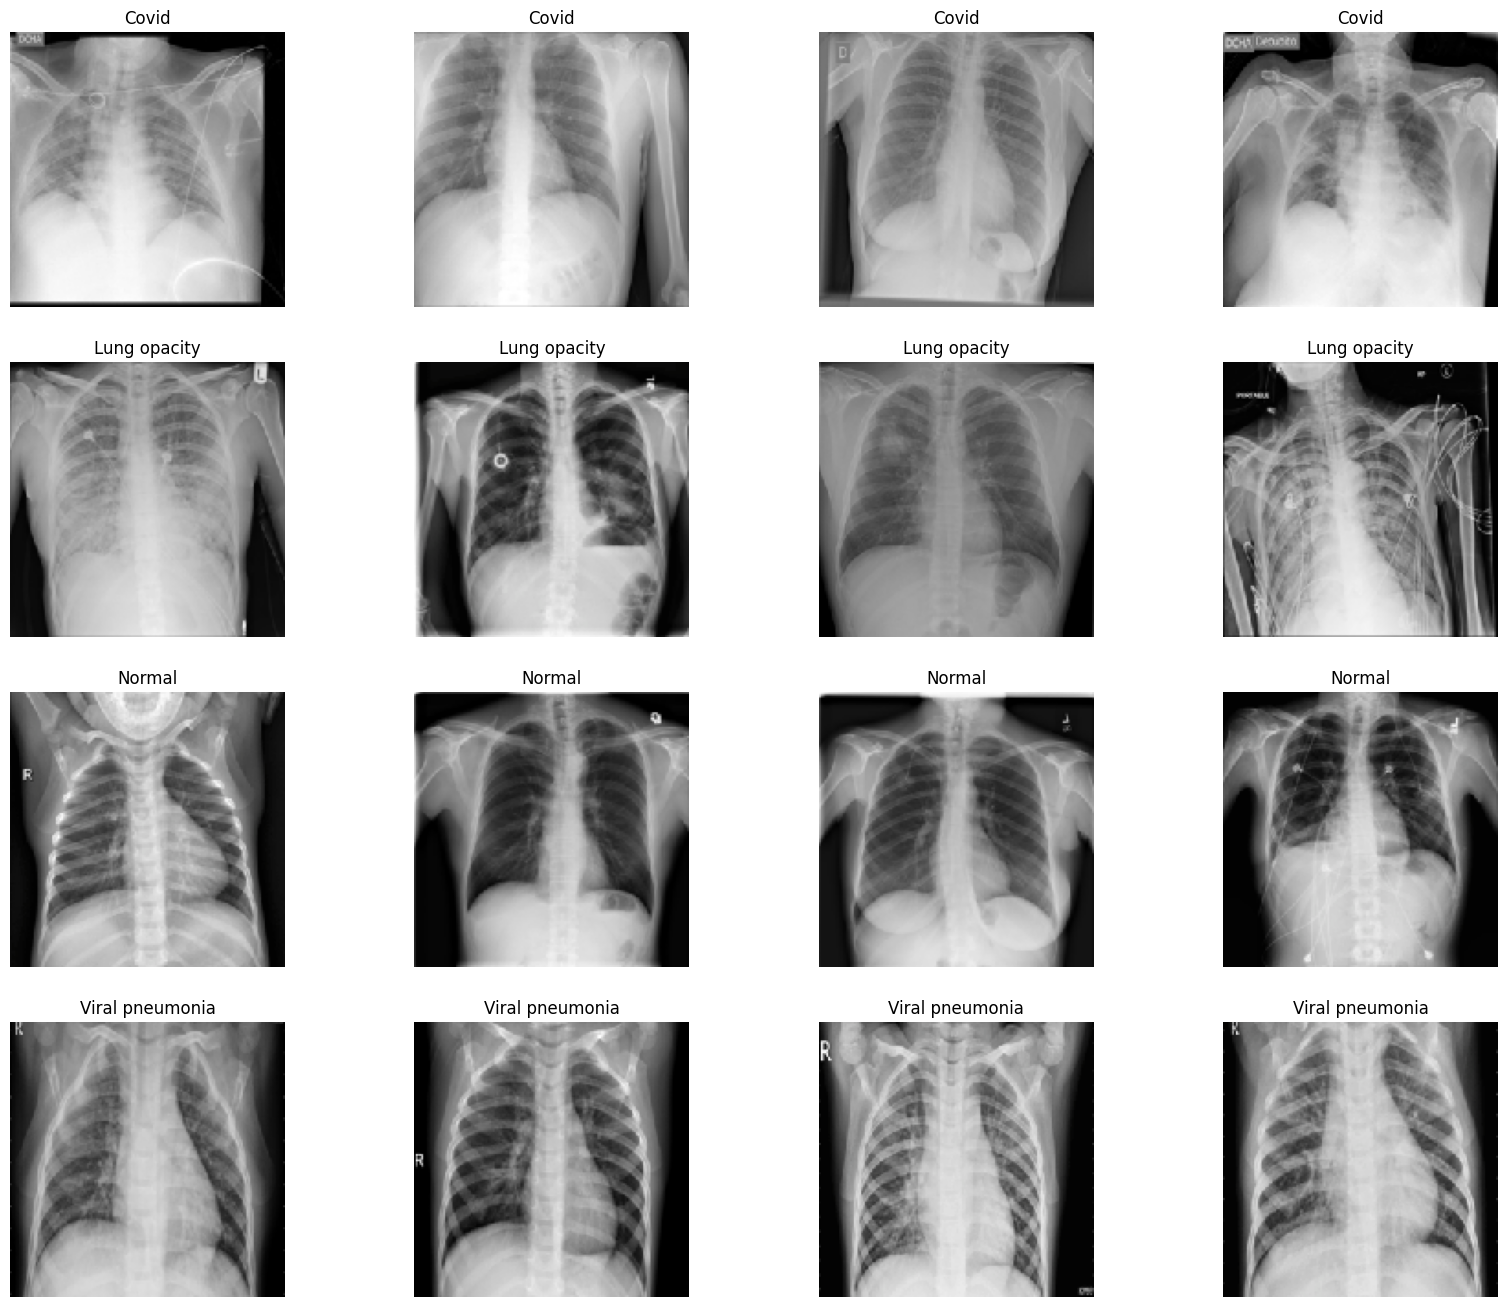

In [6]:
plt.figure(figsize=(20,25))
plot_index=1
for category in train_data.class_indices.keys():
    path=os.path.join(train_dir,category)
    img_num=1
    for img in os.listdir(path):
        if img_num<=4:
            img_path=os.path.join(path,img)
            img=load_img(img_path,target_size=img_size)
            plt.subplot(6,4,plot_index)
            plt.title(category.capitalize())
            plt.axis('off')
            plt.imshow(img)
            img_num+=1
            plot_index+=1
        else:
            break  
plt.show()

## Modeling

In [7]:
model=Sequential()
model.add(Input(shape=(150,150,1)))

model.add(Conv2D(16,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(BatchNormalization())

model.add(Conv2D(32,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(BatchNormalization())

model.add(Conv2D(64,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(BatchNormalization())

model.add(Conv2D(128,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(BatchNormalization())

model.add(Flatten())
model.add(Dropout(0.4))
model.add(Dense(32,activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(16,activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(4,activation='softmax'))

model.summary()

2026-04-26 15:28:34.234615: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 75, 75, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 37, 37, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 18, 18, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 9, 9, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       331,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 430,516 (1.64 MB)

 Trainable params: 430,036 (1.64 MB)

 Non-trainable params: 480 (1.88 KB)

In [8]:
cp=ModelCheckpoint( 'Augmented_Covid_CXR_weights.keras',
                    monitor='val_loss',
                    save_best_only=True,
                    verbose=1)
early_stopping=EarlyStopping( monitor='val_loss',
                            min_delta=0.001,
                            patience=5,
                            restore_best_weights=True,
                            verbose=1
                            )
ReduceLR=ReduceLROnPlateau(monitor='val_loss',
                            factor=0.5,
                            patience=5,
                            min_delta=0.001,
                            verbose=1)
callbacks=[cp,early_stopping,ReduceLR]

In [9]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [10]:
history=model.fit(train_data,validation_data=val_data,steps_per_epoch=train_data.samples//train_data.batch_size,epochs=epochs,callbacks=callbacks)

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 933ms/step - accuracy: 0.4485 - loss: 1.2538
Epoch 1: val_loss improved from inf to 1.85796, saving model to Augmented_Covid_CXR_weights.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 410s 1s/step - accuracy: 0.4487 - loss: 1.2534 - val_accuracy: 0.4812 - val_loss: 1.8580 - learning_rate: 0.0010
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 926ms/step - accuracy: 0.6830 - loss: 0.8061
Epoch 2: val_loss improved from 1.85796 to 0.61078, saving model to Augmented_Covid_CXR_weights.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 386s 1s/step - accuracy: 0.6830 - loss: 0.8060 - val_accuracy: 0.7881 - val_loss: 0.6108 - learning_rate: 0.0010
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 911ms/step - accuracy: 0.7662 - loss: 0.6312
Epoch 3: val_loss improved from 0.61078 to 0.42272, saving model to Augmented_Covid_CXR_weights.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 381s 1s/step - accuracy: 0.7663 - loss: 0.6311 - val_accuracy: 0.8588 - val_loss: 0.4227 - learning_rate: 0.0010
Epoch 4/

## Evaluation

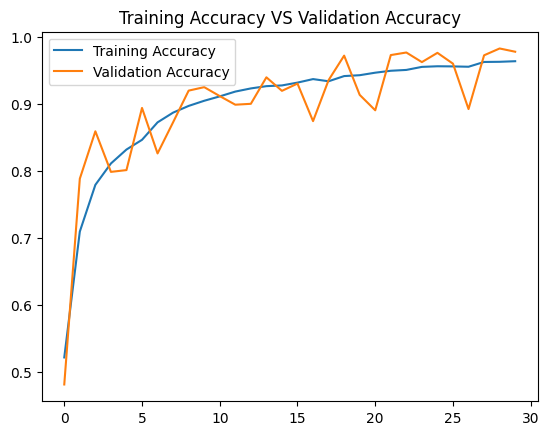

In [11]:
plt.title("Training Accuracy VS Validation Accuracy")
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.legend()
plt.show()

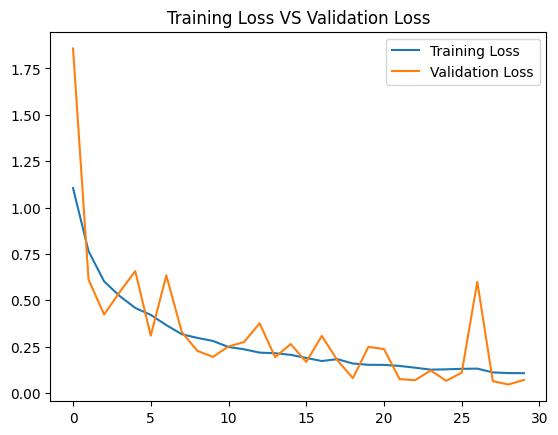

In [12]:
plt.title("Training Loss VS Validation Loss")
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.legend()
plt.show()

In [13]:
model.evaluate(val_data)

94/94 ━━━━━━━━━━━━━━━━━━━━ 40s 428ms/step - accuracy: 0.9857 - loss: 0.0347


[0.04530680552124977, 0.9823274612426758]

In [15]:
y_pred=model.predict(val_data)
y_pred[0]

94/94 ━━━━━━━━━━━━━━━━━━━━ 41s 436ms/step


array([9.9999994e-01, 1.4017839e-30, 3.1220091e-31, 0.0000000e+00],
      dtype=float32)

In [16]:
y_p=np.argmax(y_pred,axis=1)
y_p[0]

np.int64(0)

In [17]:
report=classification_report(val_data.classes,y_p)
print("Classification Report : \n"+report)

Classification Report : 
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1749
           1       0.98      0.96      0.97      1534
           2       0.96      0.98      0.97      1642
           3       1.00      1.00      1.00      1073

    accuracy                           0.98      5998
   macro avg       0.98      0.98      0.98      5998
weighted avg       0.98      0.98      0.98      5998



In [18]:
conf_mat=confusion_matrix(val_data.classes,y_p)
conf_mat

array([[1743,    4,    2,    0],
       [   5, 1469,   60,    0],
       [   4,   29, 1607,    2],
       [   0,    0,    0, 1073]])

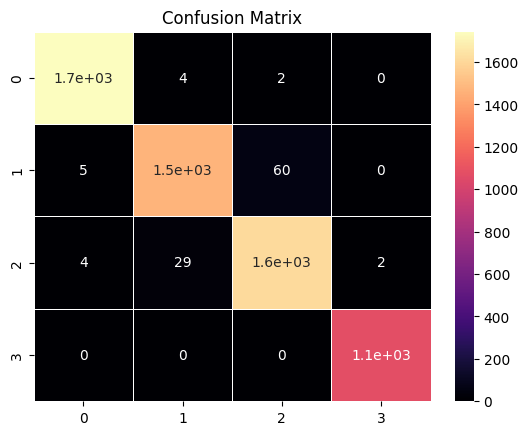

In [19]:
plt.title("Confusion Matrix")
sns.heatmap(conf_mat,annot=True,cmap='magma',linecolor='white',linewidths=0.5)
plt.show()

## Saving Model

In [20]:
model.save('Augmented_Covid_CXR_Model.h5')

## Read Prediction Images and Show it

In [21]:
pred_dir=r'/kaggle/input/datasets/hagerhabib/pred-data'
pred_data=[]
for img in tqdm(os.listdir(pred_dir)):
    img_path=os.path.join(pred_dir,img)
    image=load_img(img_path,target_size=img_size,color_mode='grayscale')
    image_array=img_to_array(image)
    image_array/=255
    pred_data.append(image_array)

100%|██████████| 4/4 [00:00<00:00, 128.58it/s]


In [22]:
pred_data=np.array(pred_data).reshape(-1,img_size[0],img_size[1],1)

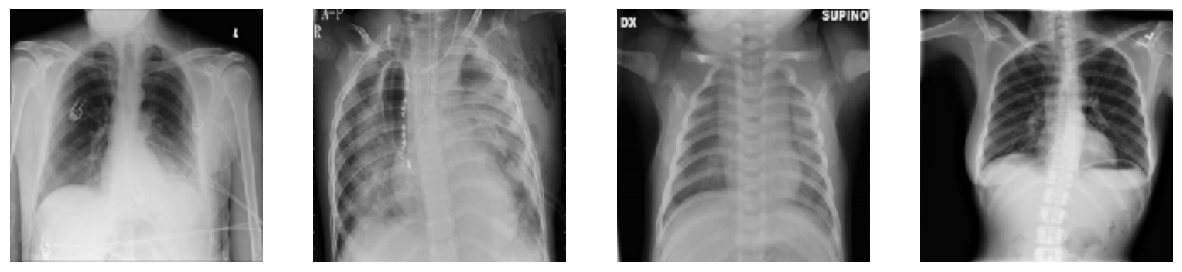

In [23]:
plt.figure(figsize=(15,15))
plot_index=1
for img in os.listdir(pred_dir):
    if plot_index<=12:
        img_path=os.path.join(pred_dir,img)
        image=load_img(img_path,target_size=img_size)
        plt.subplot(3,4,plot_index)
        plt.axis('off')
        plt.imshow(image)
        plot_index+=1
    else:
        break  
plt.show()

## Predict new images without Labels

In [24]:
images_pred=model.predict(pred_data)
images_pred[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


array([0.02266212, 0.70548624, 0.245768  , 0.02608358], dtype=float32)

In [25]:
images_pred_labels=np.argmax(images_pred,axis=1)
images_pred_labels[0]

np.int64(1)

## Show Some Prediction Images with their Prediction Labels

In [26]:
labels=[i for i in val_data.class_indices.keys()]
labels

['COVID', 'Lung opacity', 'Normal', 'Viral Pneumonia']

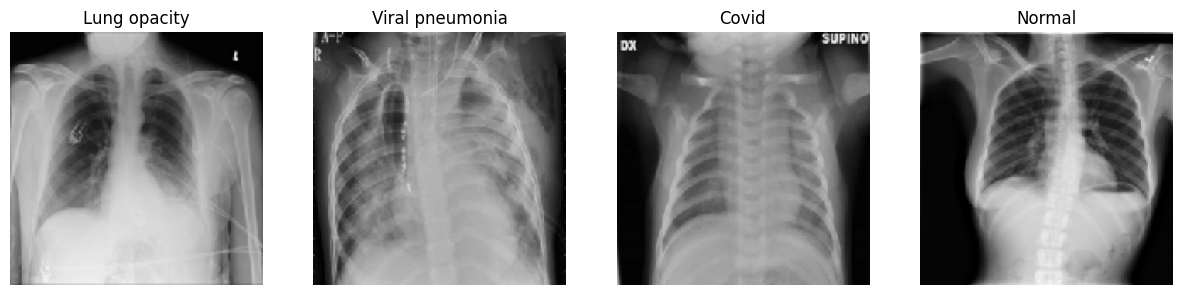

In [27]:
plt.figure(figsize=(15,25))
plot_index=1
for img in os.listdir(pred_dir):
    if plot_index<=20:
        label=labels[images_pred_labels[plot_index-1]]
        img_path=os.path.join(pred_dir,img)
        image=load_img(img_path,target_size=img_size)
        plt.subplot(5,4,plot_index)
        plt.title(label.capitalize())
        plt.axis('off')
        plt.imshow(image)
        plot_index+=1
    else:
        break  
plt.show()